Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (8,5)


Import Dataset

In [ ]:
df = pd.read_csv("/content/Diversity in tech companies (1).csv")
df.head()

,Year,Company,Female %,Male %,% White,% Asian,% Latino,% Black,% Multi,% Other,% Undeclared
0,2018,Yahoo!,37,63,45,44,4,2,2,3,-
1,2018,Google,31,69,53,36,4,3,4,0,-
2,2018,Apple,32,68,54,21,13,9,3,1,2
3,2018,Cisco,24,76,53,37,5,4,1,<1,-
4,2018,eBay,40,60,50,39,6,3,1,1,-


Basic Overview

In [41]:
# Basic overview
print("Shape (rows, cols):", df.shape)
display(df.head(5))
display(df.sample(5, random_state=42))

# Column names + dtypes
display(df.dtypes)

# Info summary
df.info()

# Missing values (count + %)
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df)) * 100
}).sort_values("missing_count", ascending=False)

display(missing.head(25))

pd.DataFrame(df.columns, columns=["Dataset Columns"])

Shape (rows, cols): (94, 33)


,Year,Female %,Male %,% White,% Asian,% Latino,% Black,% Multi,% Other,% Undeclared,...,Company_Microsoft,Company_Netflix,Company_Nvidia,Company_Pandora,Company_Salesforce,Company_Slack,Company_Uber,Company_Yahoo!,Company_Yelp,Company_eBay
0,2018,37,63,45,44.0,4.0,2.0,2.0,3.0,2.0,...,False,False,False,False,False,False,False,True,False,False
1,2018,31,69,53,36.0,4.0,3.0,4.0,0.0,2.0,...,False,False,False,False,False,False,False,False,False,False
2,2018,32,68,54,21.0,13.0,9.0,3.0,1.0,2.0,...,False,False,False,False,False,False,False,False,False,False
3,2018,24,76,53,37.0,5.0,4.0,1.0,0.5,2.0,...,False,False,False,False,False,False,False,False,False,False
4,2018,40,60,50,39.0,6.0,3.0,1.0,1.0,2.0,...,False,False,False,False,False,False,False,False,False,True


,Year,Female %,Male %,% White,% Asian,% Latino,% Black,% Multi,% Other,% Undeclared,...,Company_Microsoft,Company_Netflix,Company_Nvidia,Company_Pandora,Company_Salesforce,Company_Slack,Company_Uber,Company_Yahoo!,Company_Yelp,Company_eBay
40,2016,37,62,47,43.0,4.0,2.0,2.0,3.0,2.0,...,False,False,False,False,False,False,False,True,False,False
22,2017,37,63,45,44.0,4.0,2.0,2.0,3.0,2.0,...,False,False,False,False,False,False,False,True,False,False
55,2016,28,72,59,29.0,5.0,4.0,1.0,1.0,2.0,...,True,False,False,False,False,False,False,False,False,False
72,2015,37,63,60,13.0,9.0,15.0,2.0,3.0,2.0,...,False,False,False,False,False,False,False,False,False,False
0,2018,37,63,45,44.0,4.0,2.0,2.0,3.0,2.0,...,False,False,False,False,False,False,False,True,False,False


,0
Year,int64
Female %,int64
Male %,int64
% White,int64
% Asian,float64
% Latino,float64
% Black,float64
% Multi,float64
% Other,float64
% Undeclared,float64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 33 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Year                                  94 non-null     int64  
 1   Female %                              94 non-null     int64  
 2   Male %                                94 non-null     int64  
 3   % White                               94 non-null     int64  
 4   % Asian                               94 non-null     float64
 5   % Latino                              94 non-null     float64
 6   % Black                               94 non-null     float64
 7   % Multi                               94 non-null     float64
 8   % Other                               94 non-null     float64
 9   % Undeclared                          94 non-null     float64
 10  High_Latino                           94 non-null     int64  
 11  Company_Amazon       

,missing_count,missing_pct
Year,0,0.0
Female %,0,0.0
Male %,0,0.0
% White,0,0.0
% Asian,0,0.0
% Latino,0,0.0
% Black,0,0.0
% Multi,0,0.0
% Other,0,0.0
% Undeclared,0,0.0


,Dataset Columns
0,Year
1,Female %
2,Male %
3,% White
4,% Asian
5,% Latino
6,% Black
7,% Multi
8,% Other
9,% Undeclared


Feature Types

In [ ]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical columns:", len(num_cols))
print(num_cols)
print("\nCategorical columns:", len(cat_cols))
print(cat_cols)

Numerical columns: 4
['Year', 'Female %', 'Male %', '% White']

Categorical columns: 7
['Company', '% Asian', '% Latino', '% Black', '% Multi', '% Other', '% Undeclared']


Feature Coloumns

In [ ]:
# Columns that should be numeric percentages
percent_cols = [
    "% Asian", "% Latino", "% Black",
    "% Multi", "% Other", "% Undeclared"
]

# Replace special values
for col in percent_cols:
    df[col] = df[col].replace("-", np.nan)     # Replace '-' with NaN
    df[col] = df[col].replace("<1", 0.5)       # Replace '<1' with 0.5 (reasonable estimate)
    df[col] = pd.to_numeric(df[col])           # Convert to numeric

# Check types again
df.dtypes

,0
Year,int64
Company,object
Female %,int64
Male %,int64
% White,int64
% Asian,float64
% Latino,float64
% Black,float64
% Multi,float64
% Other,float64


In [ ]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical columns:", len(num_cols))
print(num_cols)
print("\nCategorical columns:", len(cat_cols))
print(cat_cols)

Numerical columns: 10
['Year', 'Female %', 'Male %', '% White', '% Asian', '% Latino', '% Black', '% Multi', '% Other', '% Undeclared']

Categorical columns: 1
['Company']


Target and Sensitive Values

In [ ]:
# Identify key features
key_features = df.columns.tolist()
print("Key features in the dataset:")
print(key_features)

# Choose target variable
target_variable = ["% Latino"]

# Sensitive attributes (other demographic groups)
sensitive_attributes = [
    "Female %",
    "Male %",
    "% White",
    "% Asian",
    "% Black",
    "% Multi",
    "% Other",
    "% Undeclared"
]

print("Sensitive attributes:")
print(sensitive_attributes)

# Observed features
observed_features = list(set(key_features) - set(target_variable))
print("Observed features:")
print(observed_features)

Key features in the dataset:
['Year', 'Company', 'Female %', 'Male %', '% White', '% Asian', '% Latino', '% Black', '% Multi', '% Other', '% Undeclared']
Sensitive attributes:
['Female %', 'Male %', '% White', '% Asian', '% Black', '% Multi', '% Other', '% Undeclared']
Observed features:
['% Undeclared', '% White', 'Year', '% Black', '% Asian', 'Female %', 'Male %', '% Other', 'Company', '% Multi']


Binary Target

In [ ]:
# Create binary target
median_latino = df["% Latino"].median()

df["High_Latino"] = (df["% Latino"] >= median_latino).astype(int)

df[["% Latino", "High_Latino"]].head()# Create binary target
median_latino = df["% Latino"].median()

df["High_Latino"] = (df["% Latino"] >= median_latino).astype(int)

df[["% Latino", "High_Latino"]].head()

,% Latino,High_Latino
0,4.0,0
1,4.0,0
2,13.0,1
3,5.0,0
4,6.0,0


In [ ]:
target_variable = ["High_Latino"]

Class distribution:
High_Latino
1    48
0    46
Name: count, dtype: int64

Class percentage:
High_Latino
1    0.510638
0    0.489362
Name: proportion, dtype: float64


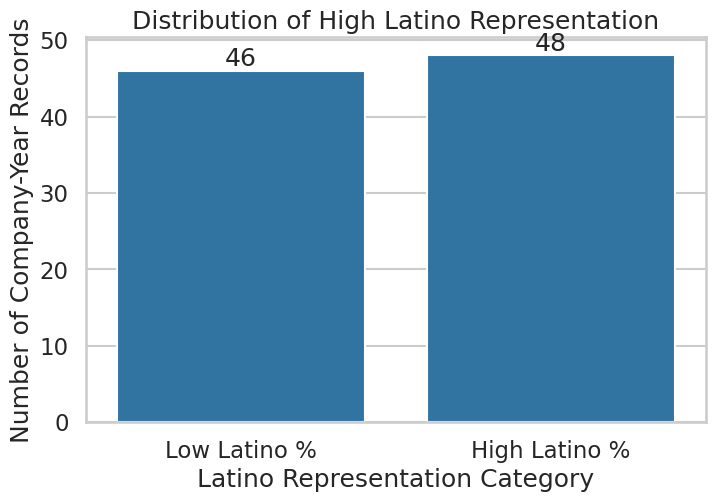

In [ ]:
print("Class distribution:")
print(df["High_Latino"].value_counts())

print("\nClass percentage:")
print(df["High_Latino"].value_counts(normalize=True))

plt.figure()
ax = sns.countplot(x="High_Latino", data=df)

plt.title("Distribution of High Latino Representation")
plt.xlabel("Latino Representation Category")
plt.ylabel("Number of Company-Year Records")
plt.xticks([0,1], ["Low Latino %", "High Latino %"])

# add counts on bars
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha="center", va="bottom")

Distribution of Target

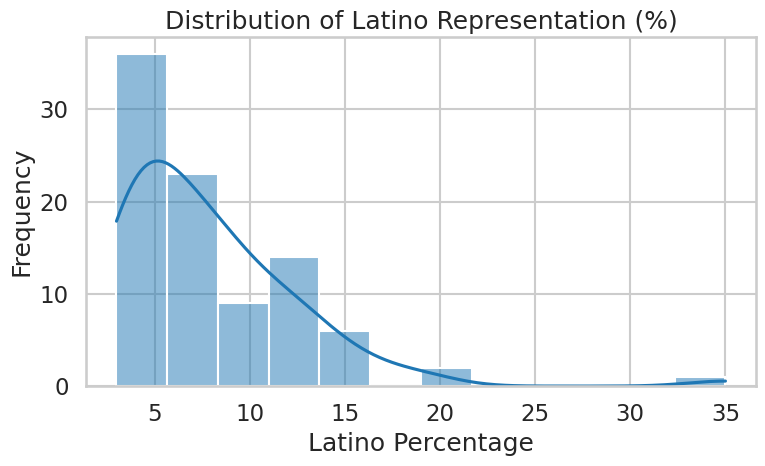

In [ ]:
plt.figure()
sns.histplot(df["% Latino"], kde=True)

plt.title("Distribution of Latino Representation (%)")
plt.xlabel("Latino Percentage")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

This histogram shows that most companies have relatively low Latino representation, with a right-skewed distribution. Only a small number of companies have very high Latino percentages. This skew may influence how the model learns patterns and contributes to disparities in predictions.

Relationship Between Sensitive Attributes & Target


Average Female % by Latino Representation:


,Female %
High_Latino,
0,33.326087
1,37.062500



Average Male % by Latino Representation:


,Male %
High_Latino,
0,66.608696
1,62.958333



Average % White by Latino Representation:


...

,% Multi
High_Latino,
0,3.846154
1,2.720000



Average % Other by Latino Representation:


,% Other
High_Latino,
0,1.402439
1,1.479167



Average % Undeclared by Latino Representation:


,% Undeclared
High_Latino,
0,4.5
1,4.2


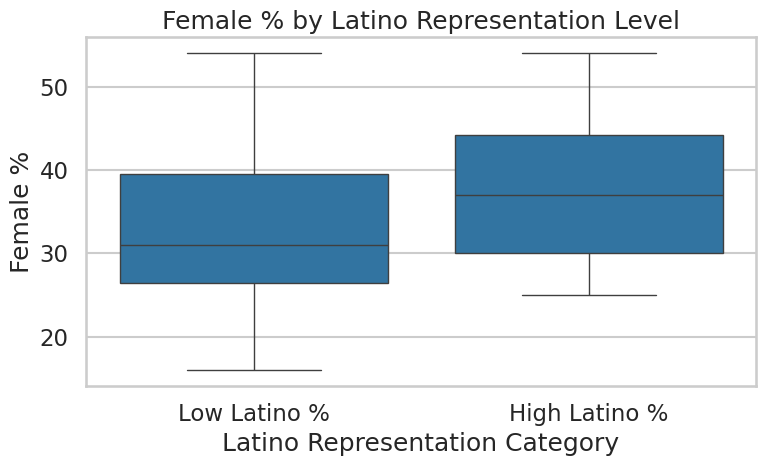

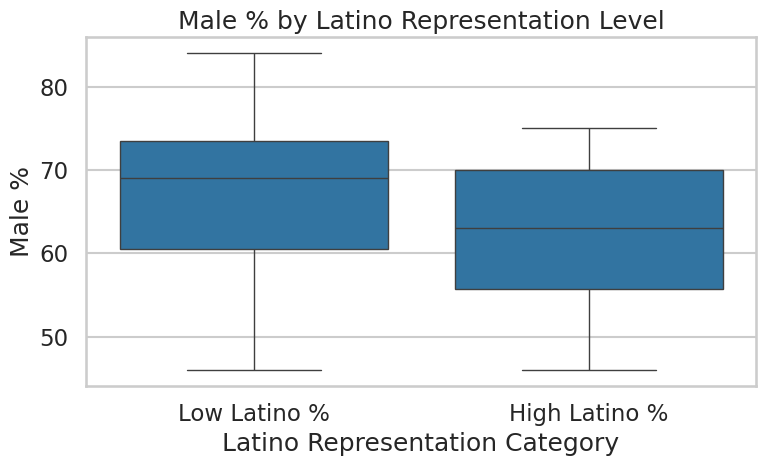

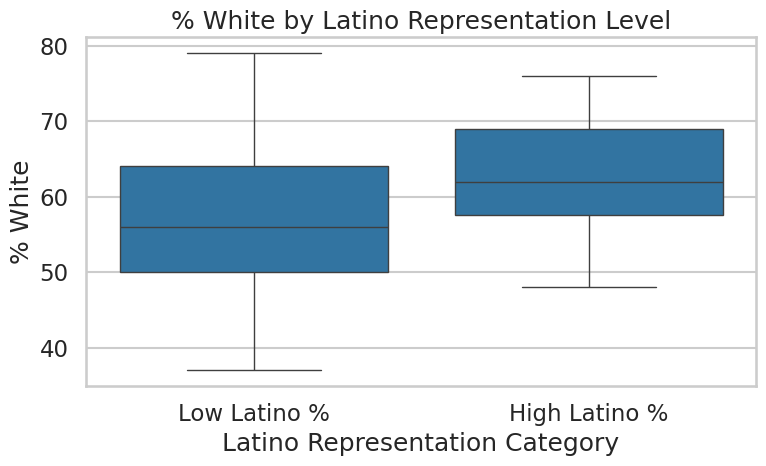

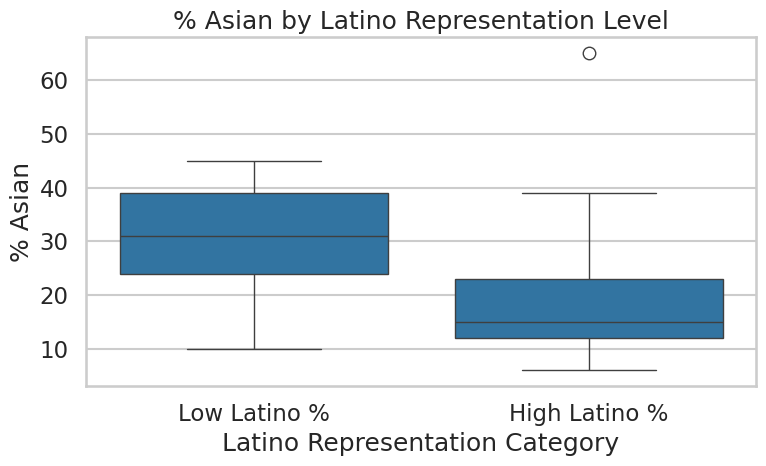

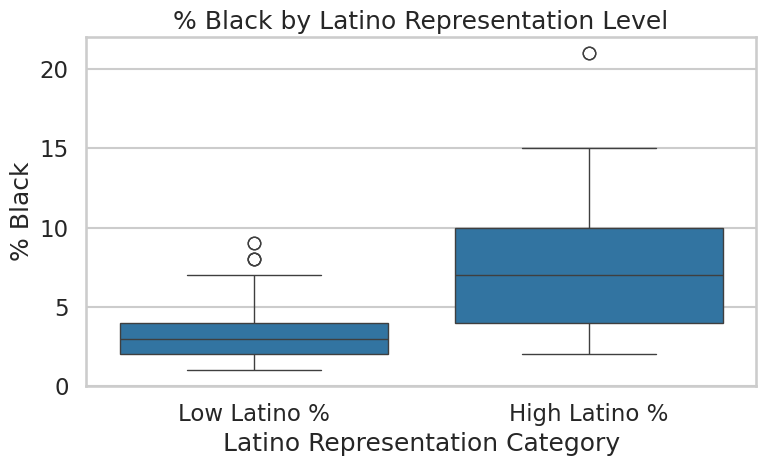

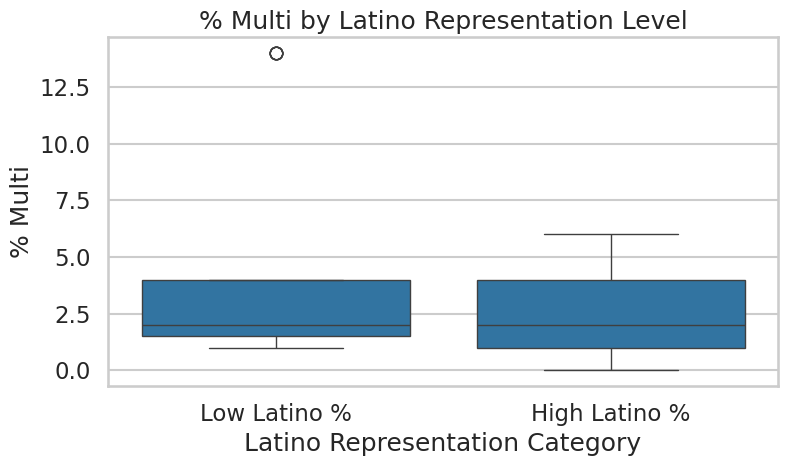

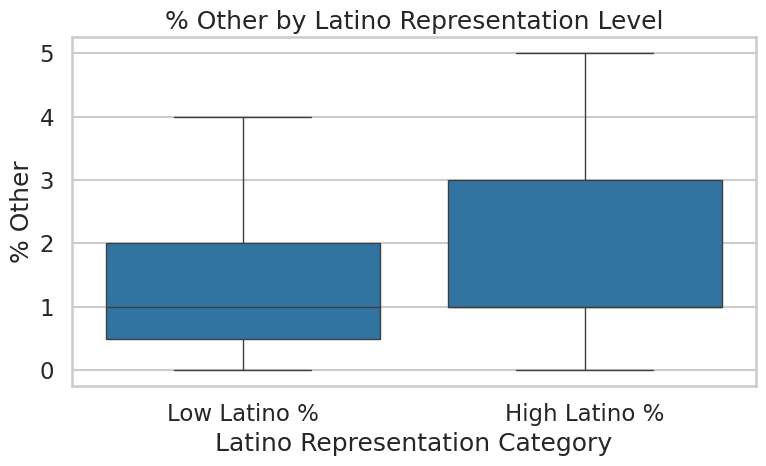

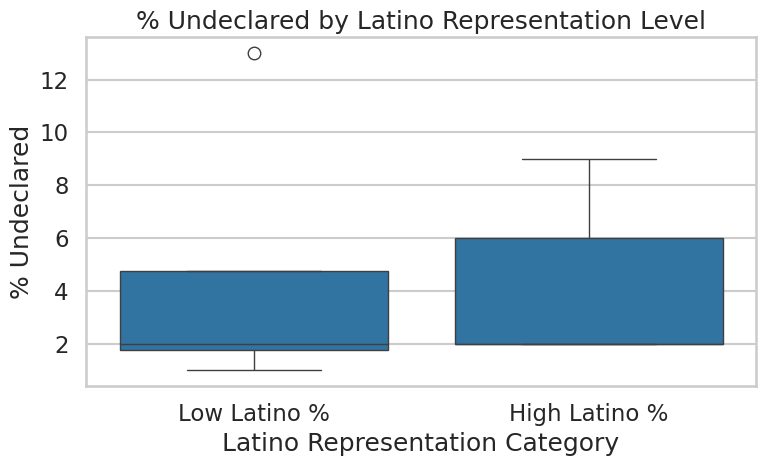

In [ ]:
for col in sensitive_attributes:
    print(f"\nAverage {col} by Latino Representation:")
    display(df.groupby("High_Latino")[col].mean())

for col in sensitive_attributes:
    plt.figure()
    sns.boxplot(x="High_Latino", y=col, data=df)
    plt.title(f"{col} by Latino Representation Level")
    plt.xlabel("Latino Representation Category")
    plt.ylabel(col)
    plt.xticks([0,1], ["Low Latino %", "High Latino %"])
    plt.tight_layout()
    plt.show()

Correlation HeatMap

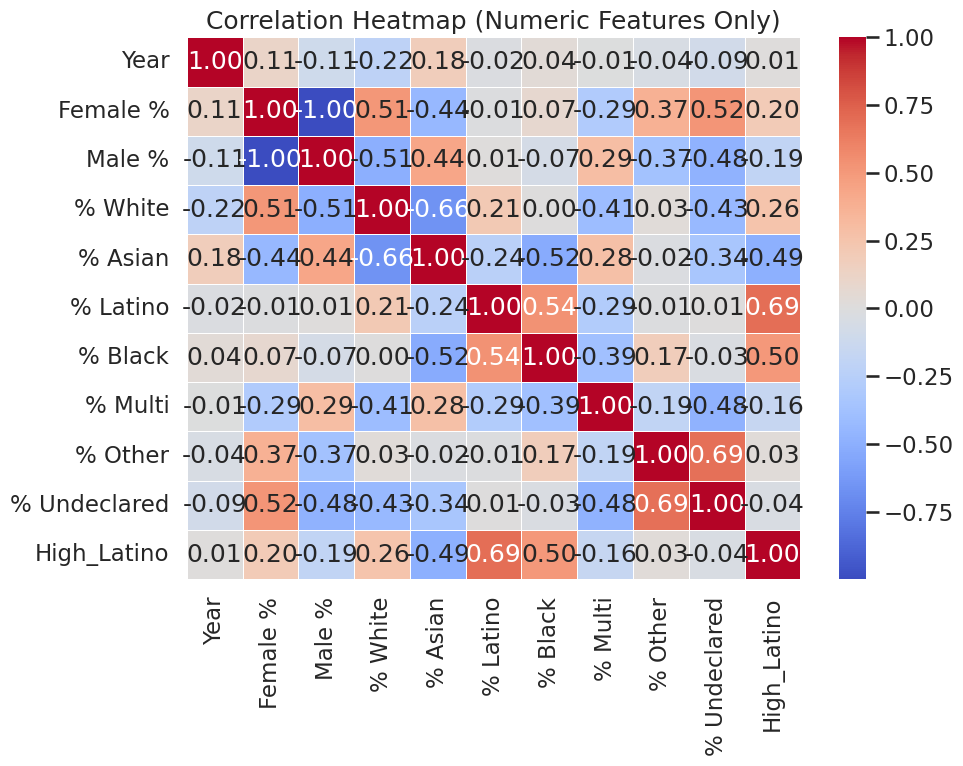

In [ ]:
plt.figure(figsize=(10,8))

corr_matrix = df.select_dtypes(include=["int64", "float64"]).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap (Numeric Features Only)")
plt.tight_layout()
plt.show()

The heatmap shows relationships between demographic features and the target variable. Several features, such as % Black and % Asian, show noticeable correlations with Latino representation. This suggests that the model may use these features as proxies, contributing to biased outcomes across groups.

Detecet Outliers

In [ ]:
# Copy dataframe so we don't modify original
df_outlier_check = df.copy()

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary[col] = len(outliers)

print("Number of outliers per numeric column:")
print(outlier_summary)

Number of outliers per numeric column:
{'Year': 0, 'Female %': 0, 'Male %': 0, '% White': 0, '% Asian': 1, '% Latino': 1, '% Black': 2, '% Multi': 5, '% Other': 0, '% Undeclared': 1, 'High_Latino': 0}


Vizualize Outliers

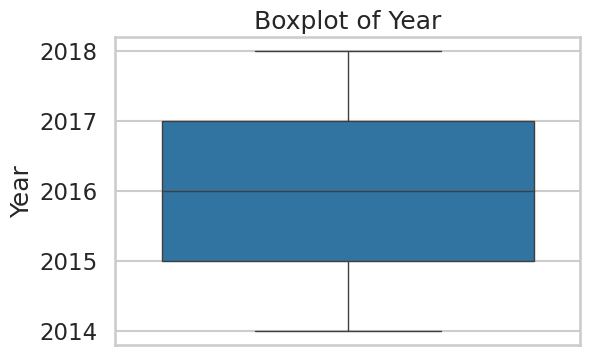

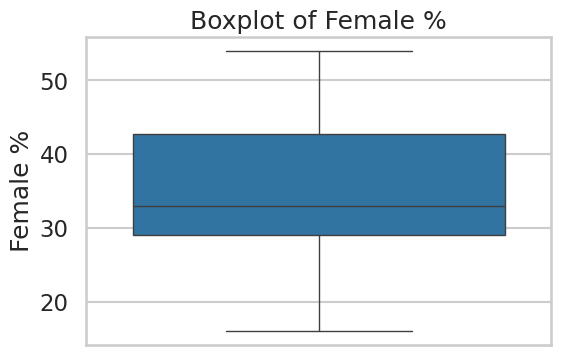

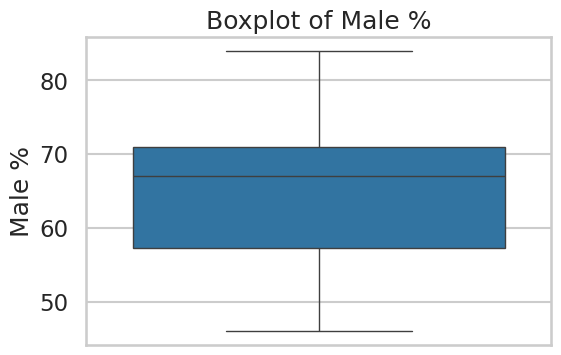

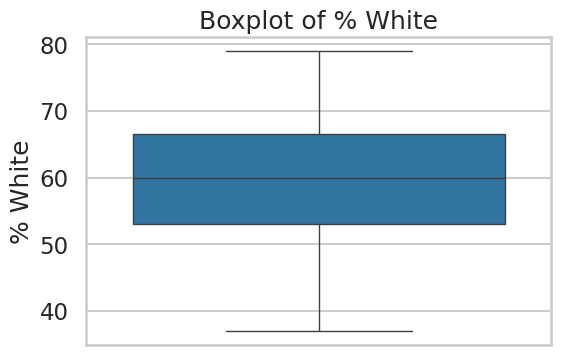

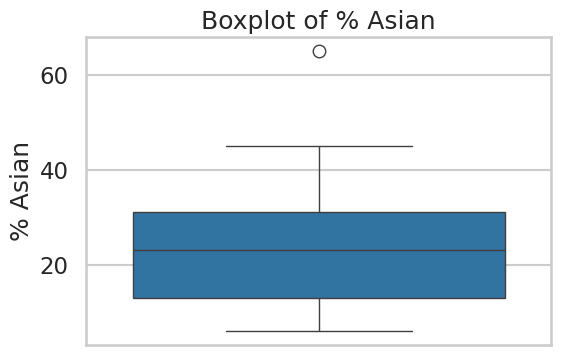

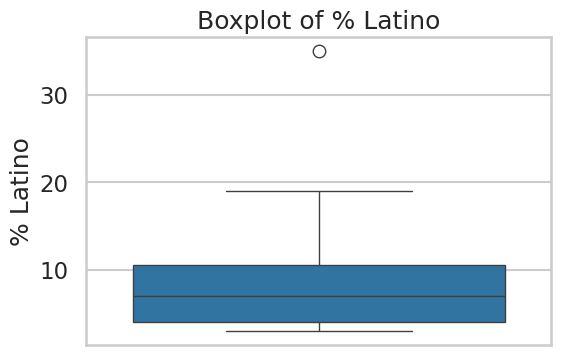

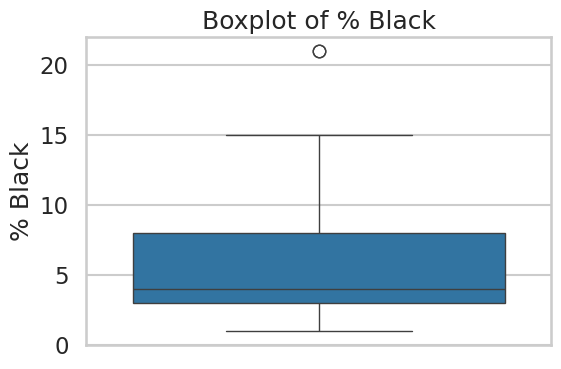

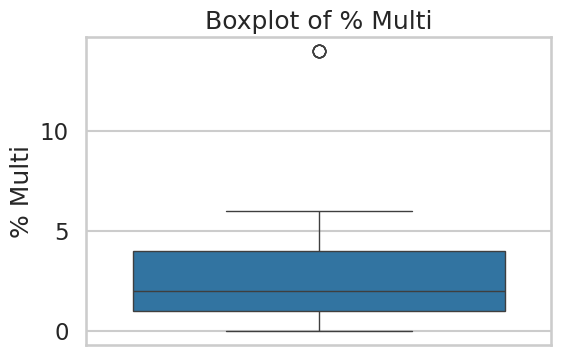

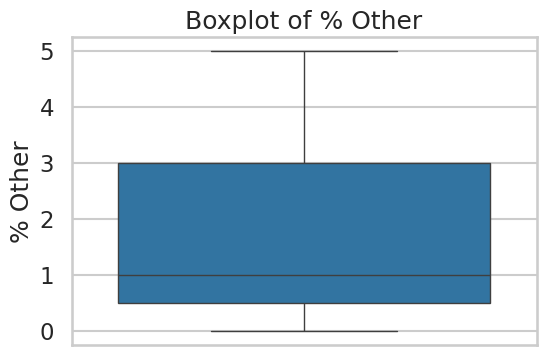

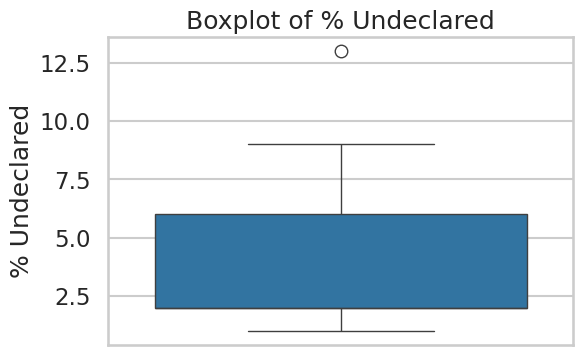

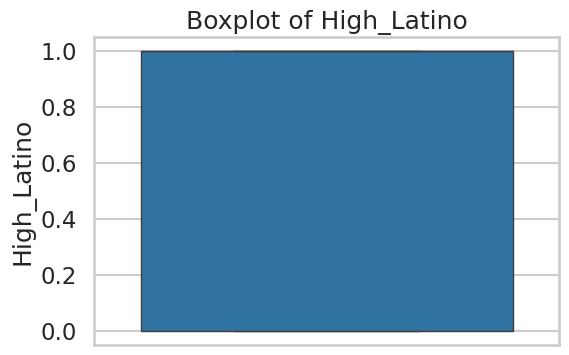

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Load the Dataset

In [ ]:
df = pd.read_csv("/content/Diversity in tech companies (2).csv")

df.head()
print(df.shape)
df.info()

(94, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Year          94 non-null     int64 
 1   Company       94 non-null     object
 2   Female %      94 non-null     int64 
 3   Male %        94 non-null     int64 
 4   % White       94 non-null     int64 
 5   % Asian       94 non-null     object
 6   % Latino      94 non-null     object
 7   % Black       94 non-null     object
 8   % Multi       94 non-null     object
 9   % Other       93 non-null     object
 10  % Undeclared  94 non-null     object
dtypes: int64(4), object(7)
memory usage: 8.2+ KB


Clean and Preprocess Percentage Columns

In [ ]:
percent_cols = [
    "% Asian", "% Latino", "% Black",
    "% Multi", "% Other", "% Undeclared"
]

for col in percent_cols:
    df[col] = df[col].replace("-", np.nan)
    df[col] = df[col].replace("<1", 0.5)
    df[col] = pd.to_numeric(df[col])

df.fillna(df.median(numeric_only=True), inplace=True)

print(df.isna().sum())

Year            0
Company         0
Female %        0
Male %          0
% White         0
% Asian         0
% Latino        0
% Black         0
% Multi         0
% Other         0
% Undeclared    0
dtype: int64


Create the Binary Target Variable

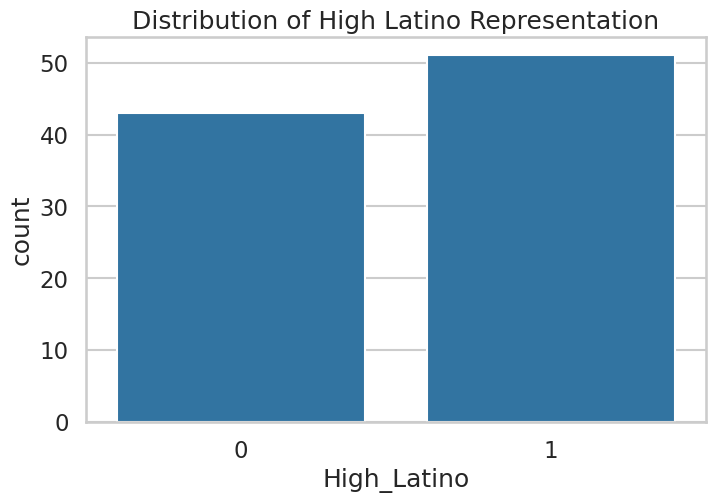

In [43]:
median_latino = df["% Latino"].median()
# Create protected attributes (binary versions)
df["High_Female"] = (df["Female %"] >= df["Female %"].median()).astype(int)
df["High_White"] = (df["% White"] >= df["% White"].median()).astype(int)
df["High_Asian"] = (df["% Asian"] >= df["% Asian"].median()).astype(int)
df["High_Black"] = (df["% Black"] >= df["% Black"].median()).astype(int)

df["High_Latino"] = (df["% Latino"] >= median_latino).astype(int)

df[["% Latino", "High_Latino"]].head()

sns.countplot(x="High_Latino", data=df)
plt.title("Distribution of High Latino Representation")
plt.show()

This graph shows the distribution of the target variable, High Latino representation. The classes are relatively balanced, meaning the model is not heavily biased due to class imbalance. This allows us to better attribute differences in predictions to potential bias rather than uneven data distribution.

Encode Categorical Variables

In [ ]:
df = pd.get_dummies(df, columns=["Company"], drop_first=True)

df.head()

,Year,Female %,Male %,% White,% Asian,% Latino,% Black,% Multi,% Other,% Undeclared,...,Company_Microsoft,Company_Netflix,Company_Nvidia,Company_Pandora,Company_Salesforce,Company_Slack,Company_Uber,Company_Yahoo!,Company_Yelp,Company_eBay
0,2018,37,63,45,44.0,4.0,2.0,2.0,3.0,2.0,...,False,False,False,False,False,False,False,True,False,False
1,2018,31,69,53,36.0,4.0,3.0,4.0,0.0,2.0,...,False,False,False,False,False,False,False,False,False,False
2,2018,32,68,54,21.0,13.0,9.0,3.0,1.0,2.0,...,False,False,False,False,False,False,False,False,False,False
3,2018,24,76,53,37.0,5.0,4.0,1.0,0.5,2.0,...,False,False,False,False,False,False,False,False,False,False
4,2018,40,60,50,39.0,6.0,3.0,1.0,1.0,2.0,...,False,False,False,False,False,False,False,False,False,True


Select Features and Target

In [ ]:
target = "High_Latino"

company_cols = [col for col in df.columns if col.startswith("Company_")]

features = [
    "Year",
    "Female %",
    "Male %",
    "% White",
    "% Asian",
    "% Black",
    "% Multi",
    "% Other",
    "% Undeclared"
] + company_cols

X = df[features]
y = df[target]

print("Number of features:", len(features))
print(features)

Number of features: 31
['Year', 'Female %', 'Male %', '% White', '% Asian', '% Black', '% Multi', '% Other', '% Undeclared', 'Company_Amazon', 'Company_Apple', 'Company_Apple (excluding undeclared)', 'Company_Cisco', 'Company_Dell', 'Company_Etsy ', 'Company_Google', 'Company_Groupon', 'Company_HP', 'Company_Indiegogo', 'Company_Ingram Micro', 'Company_Intel', 'Company_Microsoft', 'Company_Netflix', 'Company_Nvidia', 'Company_Pandora', 'Company_Salesforce', 'Company_Slack', 'Company_Uber', 'Company_Yahoo!', 'Company_Yelp', 'Company_eBay']


Split the Data into Training and Testing Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training cases:", X_train.shape[0])
print("Test cases:", X_test.shape[0])

Training cases: 65
Test cases: 29


Scale Features For Logistics Regression

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression Model

In [ ]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.9655172413793104
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.94      1.00      0.97        16

    accuracy                           0.97        29
   macro avg       0.97      0.96      0.96        29
weighted avg       0.97      0.97      0.97        29



Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8620689655172413
              precision    recall  f1-score   support

           0       0.80      0.92      0.86        13
           1       0.93      0.81      0.87        16

    accuracy                           0.86        29
   macro avg       0.86      0.87      0.86        29
weighted avg       0.87      0.86      0.86        29



XGBoost

In [ ]:
xgb_model = XGBClassifier(eval_metric="logloss", random_state=42)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.8620689655172413
              precision    recall  f1-score   support

           0       0.80      0.92      0.86        13
           1       0.93      0.81      0.87        16

    accuracy                           0.86        29
   macro avg       0.86      0.87      0.86        29
weighted avg       0.87      0.86      0.86        29



Compare Model Performance

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],

    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],

    "AUC": [
        roc_auc_score(y_test, log_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs)
    ]
})
results = results.round(3)
results

,Model,Accuracy,F1 Score,AUC
0,Logistic Regression,0.966,0.970,0.995
1,Random Forest,0.862,0.867,0.986
2,XGBoost,0.862,0.867,0.841


ROC Curve + AUC

Logistic AUC: 0.9951923076923077
Random Forest AUC: 0.9855769230769231
XGBoost AUC: 0.8413461538461539


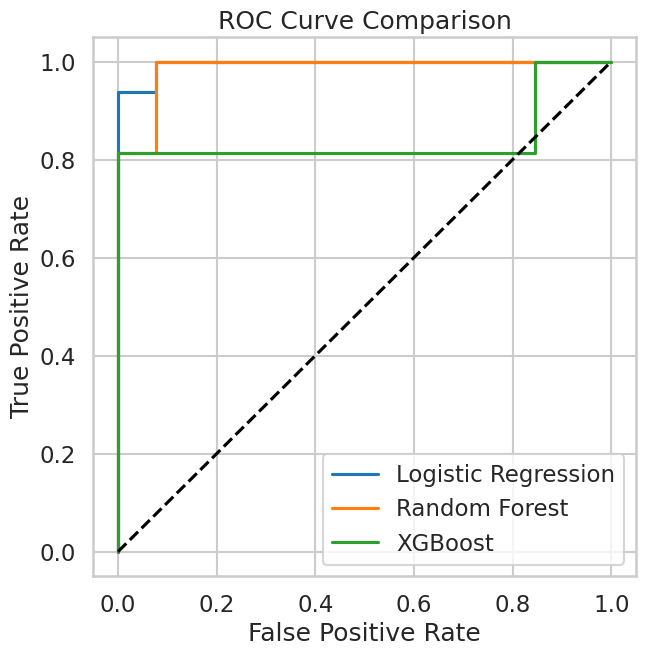

In [ ]:
print("Logistic AUC:", roc_auc_score(y_test, log_probs))
print("Random Forest AUC:", roc_auc_score(y_test, rf_probs))
print("XGBoost AUC:", roc_auc_score(y_test, xgb_probs))

fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(7, 7))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

This graph compares the performance of Logistic Regression, Random Forest, and XGBoost using ROC curves. All models perform well, with Logistic Regression showing the highest AUC, indicating strong overall classification ability. However, strong performance does not guarantee fairness, which is why further bias analysis is necessar

Subgroup Analysis

In [44]:
high_female = df.loc[X_test.index, "High_Female"] == 1
low_female = df.loc[X_test.index, "High_Female"] == 0

print("Logistic Regression - High Female Accuracy:",
      f"{accuracy_score(y_test[high_female], log_pred[high_female]):.3f}")
print("Logistic Regression - Low Female Accuracy:",
      f"{accuracy_score(y_test[low_female], log_pred[low_female]):.3f}")

print("Random Forest - High Female Accuracy:",
      f"{accuracy_score(y_test[high_female], rf_pred[high_female]):.3f}")
print("Random Forest - Low Female Accuracy:",
      f"{accuracy_score(y_test[low_female], rf_pred[low_female]):.3f}")

print("XGBoost - High Female Accuracy:",
      f"{accuracy_score(y_test[high_female], xgb_pred[high_female]):.3f}")
print("XGBoost - Low Female Accuracy:",
      f"{accuracy_score(y_test[low_female], xgb_pred[low_female]):.3f}")

Logistic Regression - High Female Accuracy: 1.000
Logistic Regression - Low Female Accuracy: 0.889
Random Forest - High Female Accuracy: 0.800
Random Forest - Low Female Accuracy: 1.000
XGBoost - High Female Accuracy: 0.800
XGBoost - Low Female Accuracy: 1.000


Train and Evaluate Binary Classification Models

In [ ]:
# Create a copy of test data with predictions
fair_df = X_test.copy()

fair_df["actual"] = y_test.values
fair_df["log_pred"] = log_pred
fair_df["rf_pred"] = rf_pred
fair_df["xgb_pred"] = xgb_pred

fair_df.head()

,Year,Female %,Male %,% White,% Asian,% Black,% Multi,% Other,% Undeclared,Company_Amazon,...,Company_Salesforce,Company_Slack,Company_Uber,Company_Yahoo!,Company_Yelp,Company_eBay,actual,log_pred,rf_pred,xgb_pred
92,2014,49,51,71,12.0,3.0,6.0,1.0,2.0,False,...,False,False,False,False,False,False,1,1,1,1
84,2014,45,55,64,23.0,2.0,2.0,3.0,2.0,False,...,False,False,False,False,False,False,1,1,0,0
65,2015,33,67,72,6.0,7.0,1.0,0.5,2.0,False,...,False,False,False,False,False,False,1,1,1,1
66,2015,45,55,64,23.0,2.0,2.0,3.0,2.0,False,...,False,False,False,False,False,False,1,1,0,0
15,2018,31,69,65,24.0,3.0,3.0,0.0,2.0,False,...,True,False,False,False,False,False,0,0,0,0


Senstitive Groups

In [ ]:
# Create binary groups using median splits

fair_df["Female_Group"] = np.where(
    fair_df["Female %"] >= fair_df["Female %"].median(),
    "High Female", "Low Female"
)

fair_df["White_Group"] = np.where(
    fair_df["% White"] >= fair_df["% White"].median(),
    "High White", "Low White"
)

fair_df["Asian_Group"] = np.where(
    fair_df["% Asian"] >= fair_df["% Asian"].median(),
    "High Asian", "Low Asian"
)

fair_df["Black_Group"] = np.where(
    fair_df["% Black"] >= fair_df["% Black"].median(),
    "High Black", "Low Black"
)

fair_df[[
    "Female_Group", "White_Group", "Asian_Group", "Black_Group"
]].head()

,Female_Group,White_Group,Asian_Group,Black_Group
92,High Female,High White,Low Asian,Low Black
84,High Female,High White,High Asian,Low Black
65,Low Female,High White,Low Asian,High Black
66,High Female,High White,High Asian,Low Black
15,Low Female,High White,High Asian,Low Black


Fairness Metric Functions

In [63]:
from sklearn.metrics import confusion_matrix

def fairness_metrics(data, group_col, pred_col):
    results = []

    for group in data[group_col].unique():
        subset = data[data[group_col] == group]

        y_true = subset["High_Latino"]
        y_pred = subset[pred_col]

        # Demographic Parity
        positive_rate = (y_pred == 1).mean()

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

        # Equal Opportunity
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan

        # Equalized Odds
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

        results.append({
            "Group": group,
            "Count": len(subset),
            "Positive Rate": positive_rate,
            "TPR": tpr,
            "FPR": fpr
        })

    return pd.DataFrame(results)


def disparate_impact(df_metrics):
    min_rate = df_metrics["Positive Rate"].min()
    max_rate = df_metrics["Positive Rate"].max()

    return min_rate / max_rate if max_rate > 0 else np.nan

In [77]:
fair_df = df.loc[X_test.index].copy()

fair_df["log_pred"] = log_pred
fair_df["rf_pred"] = rf_pred
fair_df["xgb_pred"] = xgb_pred

Compute Metrics

In [78]:
fair_df = df.loc[X_test.index].copy()

fair_df["log_pred"] = log_pred
fair_df["rf_pred"] = rf_pred
fair_df["xgb_pred"] = xgb_pred

female_metrics = fairness_metrics(fair_df, "High_Female", "log_pred")
white_metrics  = fairness_metrics(fair_df, "High_White", "log_pred")
asian_metrics  = fairness_metrics(fair_df, "High_Asian", "log_pred")
black_metrics  = fairness_metrics(fair_df, "High_Black", "log_pred")

display(female_metrics)
display(white_metrics)
display(asian_metrics)
display(black_metrics)

,Group,Count,Positive Rate,TPR,FPR
0,1,20,0.650000,1.0,0.000000
1,0,9,0.444444,1.0,0.166667


,Group,Count,Positive Rate,TPR,FPR
0,1,19,0.684211,1.0,0.000000
1,0,10,0.400000,1.0,0.142857


,Group,Count,Positive Rate,TPR,FPR
0,0,15,0.800000,1.0,0.0
1,1,14,0.357143,1.0,0.1


,Group,Count,Positive Rate,TPR,FPR
0,0,12,0.333333,1.0,0.0
1,1,17,0.764706,1.0,0.2


Disparate Impact

In [79]:
print("Disparate Impact (Logistic Model)")
print("-----------------------------------")

print("Female:", round(disparate_impact(female_metrics), 3))
print("White :", round(disparate_impact(white_metrics), 3))
print("Asian :", round(disparate_impact(asian_metrics), 3))
print("Black :", round(disparate_impact(black_metrics), 3))

Disparate Impact (Logistic Model)
-----------------------------------
Female: 0.684
White : 0.585
Asian : 0.446
Black : 0.436


Combine All Metrics

In [80]:
all_metrics = pd.concat([
    female_metrics.assign(GroupType="Female"),
    white_metrics.assign(GroupType="White"),
    asian_metrics.assign(GroupType="Asian"),
    black_metrics.assign(GroupType="Black")
])

all_metrics["Group_Label"] = all_metrics["Group"].map({
    0: "Low",
    1: "High"
})

all_metrics = all_metrics[
    ["GroupType", "Group_Label", "Count", "Positive Rate", "TPR", "FPR"]
]

display(all_metrics)

,GroupType,Group_Label,Count,Positive Rate,TPR,FPR
0,Female,High,20,0.650000,1.0,0.000000
1,Female,Low,9,0.444444,1.0,0.166667
0,White,High,19,0.684211,1.0,0.000000
1,White,Low,10,0.400000,1.0,0.142857
0,Asian,Low,15,0.800000,1.0,0.000000
1,Asian,High,14,0.357143,1.0,0.100000
0,Black,Low,12,0.333333,1.0,0.000000
1,Black,High,17,0.764706,1.0,0.200000


Demographic Parity

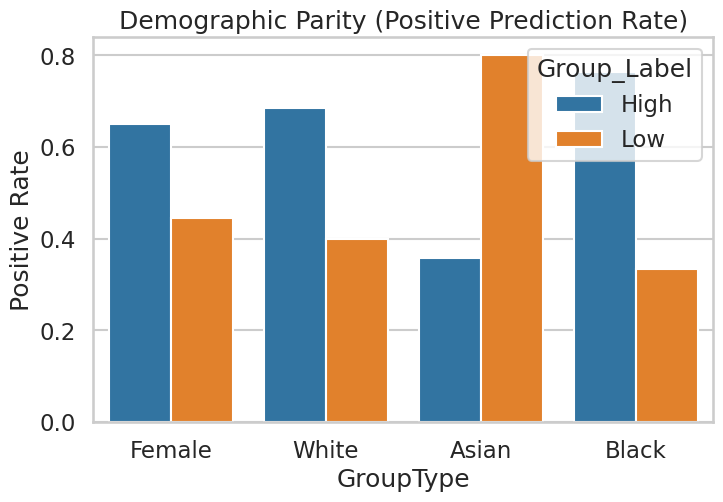

In [87]:
sns.barplot(data=all_metrics, x="GroupType", y="Positive Rate", hue="Group_Label")
plt.title("Demographic Parity (Positive Prediction Rate)")
plt.show()

This graph compares positive prediction rates across groups. There are clear differences between high and low groups, especially for Asian and Black representation, indicating that the model predicts favorable outcomes unevenly. This demonstrates a violation of Demographic Parity and is strong evidence of bias.

Equal Opportunity

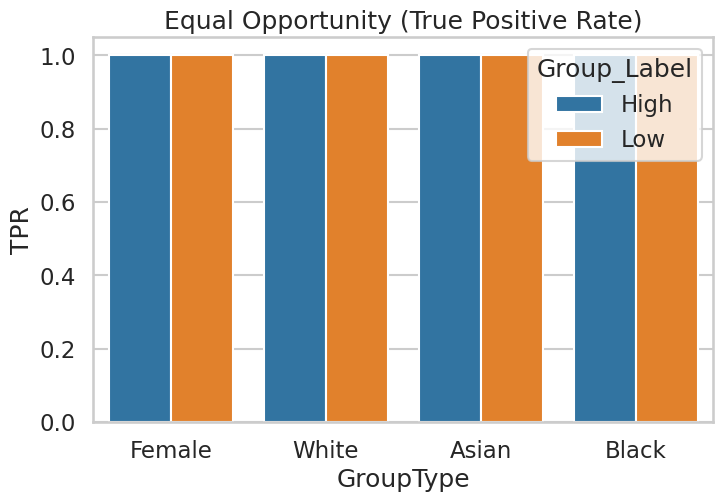

In [88]:
sns.barplot(data=all_metrics, x="GroupType", y="TPR", hue="Group_Label")
plt.title("Equal Opportunity (True Positive Rate)")
plt.show()

This graph shows that the True Positive Rate is equal across all groups. This means the model is equally good at identifying actual positive cases regardless of group. However, fairness in this metric alone does not mean the model is overall fair.

Equalized Odds

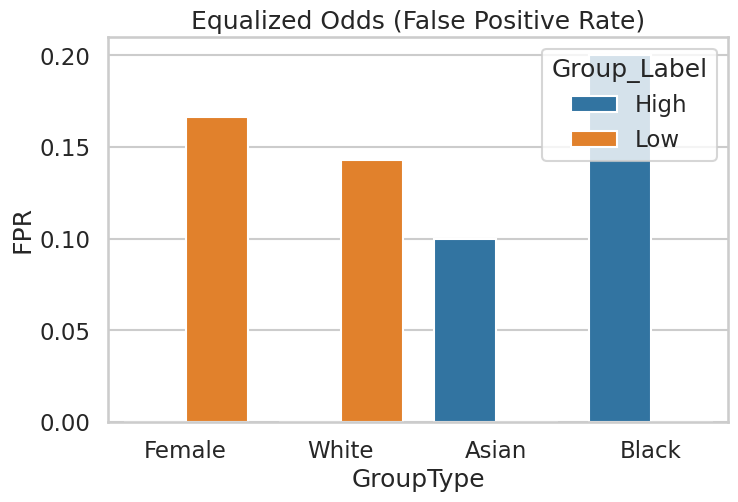

In [89]:
sns.barplot(data=all_metrics, x="GroupType", y="FPR", hue="Group_Label")
plt.title("Equalized Odds (False Positive Rate)")
plt.show()

This graph shows differences in False Positive Rates across groups. Some groups have higher error rates than others, meaning they are more likely to be incorrectly predicted as positive. This indicates a violation of Equalized Odds and further confirms bias in the model.

Confusion Matrices

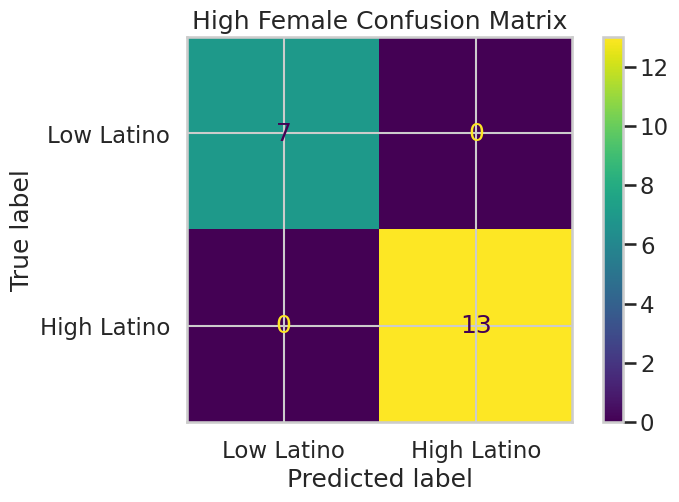

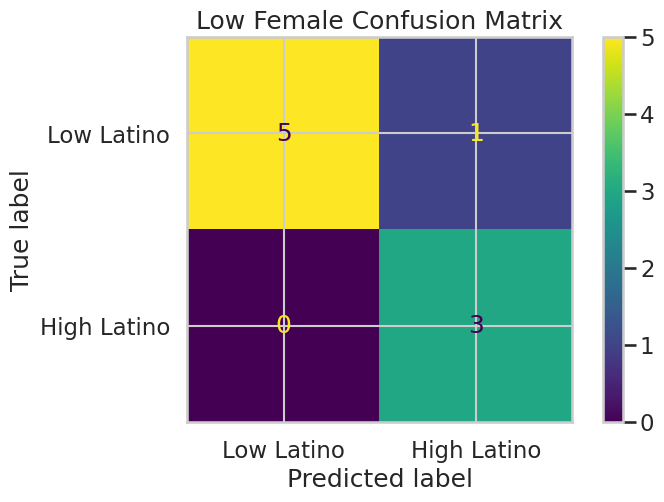

In [86]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

def plot_conf_matrix(group_col, group_value, label_name):
    subset = fair_df[fair_df[group_col] == group_value]

    cm = confusion_matrix(subset["High_Latino"], subset["log_pred"], labels=[0, 1])

    disp = ConfusionMatrixDisplay(cm, display_labels=["Low Latino", "High Latino"])
    disp.plot()
    plt.title(f"{label_name} Confusion Matrix")
    plt.show()

plot_conf_matrix("High_Female", 1, "High Female")
plot_conf_matrix("High_Female", 0, "Low Female")

These confusion matrices show how the model performs for different groups. The high female group has more correct predictions and fewer errors, while the low female group shows more misclassifications. This highlights how model performance differs across groups and reinforces the presence of bias.

The observed bias in the model is likely driven by underlying patterns in the dataset rather than the model itself. Many of the demographic features, such as % Asian and % Black, are correlated with the target variable (% Latino), meaning the model may rely on these as proxy variables even if sensitive attributes are removed. This reflects historical or structural imbalances in representation across tech companies. As a result, the model produces unequal outcomes across groups, with some groups receiving disproportionately more positive predictions and others experiencing higher error rates. These disparities highlight important ethical concerns, as biased predictions can reinforce existing inequalities and lead to unfair decision-making if deployed in real-world settings.

Bias Gap Summary

In [85]:
def gap(metric_df, col):
    return metric_df[col].max() - metric_df[col].min()

summary = pd.DataFrame({
    "Group": ["Female", "White", "Asian", "Black"],
    "DP Gap": [
        gap(female_metrics, "Positive Rate"),
        gap(white_metrics, "Positive Rate"),
        gap(asian_metrics, "Positive Rate"),
        gap(black_metrics, "Positive Rate")
    ],
    "TPR Gap": [
        gap(female_metrics, "TPR"),
        gap(white_metrics, "TPR"),
        gap(asian_metrics, "TPR"),
        gap(black_metrics, "TPR")
    ],
    "FPR Gap": [
        gap(female_metrics, "FPR"),
        gap(white_metrics, "FPR"),
        gap(asian_metrics, "FPR"),
        gap(black_metrics, "FPR")
    ]
})

summary.round(3)

,Group,DP Gap,TPR Gap,FPR Gap
0,Female,0.206,0.0,0.167
1,White,0.284,0.0,0.143
2,Asian,0.443,0.0,0.100
3,Black,0.431,0.0,0.200


Conclusion

In this project, we built models to predict whether a company has a high percentage of Latino employees and then evaluated how fair those predictions were across different demographic groups.

The models performed well overall, especially Logistic Regression, which had the highest accuracy and AUC. However, when we looked at fairness metrics, we saw that the model did not treat all groups the same.

Demographic parity showed noticeable differences in how often each group received positive predictions. The Asian and Black group splits had the largest gaps, while the Female split was more balanced.

Equal opportunity showed no difference across groups since all true positive rates were 1.0, but this is likely because the dataset is small.

Equalized odds revealed differences in false positive rates, especially for the Black group split, meaning some groups were more likely to be incorrectly predicted as positive.

Disparate impact also confirmed that some groups were treated more equally than others, with the Female group being the most balanced and the Asian group showing the biggest disparity.

Overall, this project shows that even when a model has high accuracy, it can still have fairness issues. These differences likely come from the small size of the dataset, the use of company-level data, and existing inequalities in tech workforce demographics.

This highlights the importance of checking fairness, not just performance, when building machine learning models.

# ============================================================
# Bias Mitigation Focus
# ============================================================

print("""
Bias Mitigation Focus:

Based on the baseline fairness results, the largest disparities were found in:
1. Asian representation groups
2. Black representation groups

These groups had the biggest differences in positive prediction rates, meaning the model predicted
High Latino representation very differently depending on whether a company had high or low Asian
or Black representation.

This matters because it suggests the model is using demographic composition as a signal, which can
lead to unequal outcomes across groups.

Mitigation methods tested:
1. Suppression: remove the protected attribute
2. Reweighing: give different weights to samples
3. Sampling: balance group/outcome combinations
4. Massaging: flip a small number of labels near the decision boundary
""")


Bias Mitigation Focus:

Based on the baseline fairness results, the largest disparities were found in:
1. Asian representation groups
2. Black representation groups

These groups had the biggest differences in positive prediction rates, meaning the model predicted
High Latino representation very differently depending on whether a company had high or low Asian
or Black representation.

This matters because it suggests the model is using demographic composition as a signal, which can
lead to unequal outcomes across groups.

Mitigation methods tested:
1. Suppression: remove the protected attribute
2. Reweighing: give different weights to samples
3. Sampling: balance group/outcome combinations
4. Massaging: flip a small number of labels near the decision boundary



In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.utils import resample
import pandas as pd
import numpy as np

# protected groups we are focusing on
protected_attrs = {
    "Asian": {
        "binary_col": "High_Asian",
        "raw_col": "% Asian"
    },
    "Black": {
        "binary_col": "High_Black",
        "raw_col": "% Black"
    }
}

def get_metrics_for_model(model_name, protected_col, preds):
    temp = df.loc[X_test.index].copy()
    temp["pred"] = preds
    metrics = fairness_metrics(temp, protected_col, "pred")
    metrics["Model"] = model_name
    metrics["Protected Attribute"] = protected_col
    return metrics


def positive_rate_gap(metrics):
    return metrics["Positive Rate"].max() - metrics["Positive Rate"].min()


def run_baseline(protected_col):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    metrics = get_metrics_for_model("Baseline", protected_col, preds)
    return metrics, accuracy_score(y_test, preds)


def run_suppression(protected_col, raw_col):
    # Remove the protected demographic feature
    X_train_sup = X_train.drop(columns=[raw_col])
    X_test_sup = X_test.drop(columns=[raw_col])

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_sup, y_train)
    preds = model.predict(X_test_sup)

    metrics = get_metrics_for_model("Suppression", protected_col, preds)
    return metrics, accuracy_score(y_test, preds)


def run_reweighing(protected_col):
    train_df = X_train.copy()
    train_df["target"] = y_train
    train_df["protected"] = df.loc[X_train.index, protected_col]

    total = len(train_df)

    weights = []
    for _, row in train_df.iterrows():
        g = row["protected"]
        y_val = row["target"]

        p_g = (train_df["protected"] == g).mean()
        p_y = (train_df["target"] == y_val).mean()
        p_gy = ((train_df["protected"] == g) & (train_df["target"] == y_val)).mean()

        weight = (p_g * p_y) / p_gy if p_gy > 0 else 1
        weights.append(weight)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train, sample_weight=weights)
    preds = model.predict(X_test)

    metrics = get_metrics_for_model("Reweighing", protected_col, preds)
    return metrics, accuracy_score(y_test, preds)


def run_sampling(protected_col):
    train_df = X_train.copy()
    train_df["target"] = y_train
    train_df["protected"] = df.loc[X_train.index, protected_col]

    groups = []
    max_size = train_df.groupby(["protected", "target"]).size().max()

    for (g, y_val), group in train_df.groupby(["protected", "target"]):
        sampled_group = resample(
            group,
            replace=True,
            n_samples=max_size,
            random_state=42
        )
        groups.append(sampled_group)

    sampled_df = pd.concat(groups)

    X_train_sampled = sampled_df.drop(columns=["target", "protected"])
    y_train_sampled = sampled_df["target"]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_sampled, y_train_sampled)
    preds = model.predict(X_test)

    metrics = get_metrics_for_model("Sampling", protected_col, preds)
    return metrics, accuracy_score(y_test, preds)


def run_massaging(protected_col):
    train_df = X_train.copy()
    train_df["target"] = y_train
    train_df["protected"] = df.loc[X_train.index, protected_col]

    # Train ranker to find cases near decision boundary
    ranker = LogisticRegression(max_iter=1000)
    ranker.fit(X_train, y_train)
    train_df["prob"] = ranker.predict_proba(X_train)[:, 1]

    # Find which group is disadvantaged based on actual positive rate
    rates = train_df.groupby("protected")["target"].mean()
    disadvantaged = rates.idxmin()
    advantaged = rates.idxmax()

    # Estimate how many labels to flip
    gap = rates.max() - rates.min()
    n_flip = int(round(gap * min(
        len(train_df[train_df["protected"] == disadvantaged]),
        len(train_df[train_df["protected"] == advantaged])
    ) / 2))

    train_massaged = train_df.copy()

    # Promote disadvantaged negative examples closest to becoming positive
    promote_idx = train_massaged[
        (train_massaged["protected"] == disadvantaged) &
        (train_massaged["target"] == 0)
    ].sort_values("prob", ascending=False).head(n_flip).index

    # Demote advantaged positive examples closest to becoming negative
    demote_idx = train_massaged[
        (train_massaged["protected"] == advantaged) &
        (train_massaged["target"] == 1)
    ].sort_values("prob", ascending=True).head(n_flip).index

    train_massaged.loc[promote_idx, "target"] = 1
    train_massaged.loc[demote_idx, "target"] = 0

    X_train_massaged = train_massaged.drop(columns=["target", "protected", "prob"])
    y_train_massaged = train_massaged["target"]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_massaged, y_train_massaged)
    preds = model.predict(X_test)

    metrics = get_metrics_for_model("Massaging", protected_col, preds)
    return metrics, accuracy_score(y_test, preds)


# ============================================================
# Run all mitigation methods for Asian and Black
# ============================================================

all_results = []
summary_results = []

for group_name, info in protected_attrs.items():
    protected_col = info["binary_col"]
    raw_col = info["raw_col"]

    methods = [
        run_baseline(protected_col),
        run_suppression(protected_col, raw_col),
        run_reweighing(protected_col),
        run_sampling(protected_col),
        run_massaging(protected_col)
    ]

    for metrics, acc in methods:
        method_name = metrics["Model"].iloc[0]
        gap = positive_rate_gap(metrics)
        di = disparate_impact(metrics)

        all_results.append(metrics)

        summary_results.append({
            "Protected Group": group_name,
            "Method": method_name,
            "Accuracy": acc,
            "Positive Rate Gap": gap,
            "Disparate Impact": di
        })

mitigation_metrics = pd.concat(all_results).reset_index(drop=True)
mitigation_summary = pd.DataFrame(summary_results)

display(mitigation_summary)
display(mitigation_metrics)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,Protected Group,Method,Accuracy,Positive Rate Gap,Disparate Impact
0,Asian,Baseline,0.758621,0.442857,0.446429
1,Asian,Suppression,0.758621,0.442857,0.446429
2,Asian,Reweighing,0.655172,0.242857,0.595238
3,Asian,Sampling,0.655172,0.242857,0.595238
4,Asian,Massaging,0.620690,0.176190,0.669643
5,Black,Baseline,0.758621,0.857843,0.088542
6,Black,Suppression,0.931034,0.490196,0.404762
7,Black,Reweighing,0.793103,0.799020,0.094444
8,Black,Sampling,0.896552,0.313725,0.515152
9,Black,Massaging,0.724138,0.490196,0.404762


,Group,Count,Positive Rate,TPR,FPR,Model,Protected Attribute
0,0,15,0.800000,1.000000,0.000,Baseline,High_Asian
1,1,14,0.357143,0.250000,0.400,Baseline,High_Asian
2,0,15,0.800000,1.000000,0.000,Suppression,High_Asian
3,1,14,0.357143,0.250000,0.400,Suppression,High_Asian
4,0,15,0.600000,0.750000,0.000,Reweighing,High_Asian
5,1,14,0.357143,0.250000,0.400,Reweighing,High_Asian
6,0,15,0.600000,0.750000,0.000,Sampling,High_Asian
7,1,14,0.357143,0.250000,0.400,Sampling,High_Asian
8,0,15,0.533333,0.666667,0.000,Massaging,High_Asian
9,1,14,0.357143,0.250000,0.400,Massaging,High_Asian


In [92]:
mitigation_summary.sort_values(
    by=["Protected Group", "Positive Rate Gap"]
)

,Protected Group,Method,Accuracy,Positive Rate Gap,Disparate Impact
4,Asian,Massaging,0.620690,0.176190,0.669643
2,Asian,Reweighing,0.655172,0.242857,0.595238
3,Asian,Sampling,0.655172,0.242857,0.595238
0,Asian,Baseline,0.758621,0.442857,0.446429
1,Asian,Suppression,0.758621,0.442857,0.446429
8,Black,Sampling,0.896552,0.313725,0.515152
6,Black,Suppression,0.931034,0.490196,0.404762
9,Black,Massaging,0.724138,0.490196,0.404762
7,Black,Reweighing,0.793103,0.799020,0.094444
5,Black,Baseline,0.758621,0.857843,0.088542



======================
FINAL CONCLUSION
======================

In this project, I analyzed bias in a machine learning model predicting whether a tech company has high Latino representation.
The target variable was created using a median split on % Latino, forming a binary classification problem (High vs Low Latino).

The baseline model showed clear evidence of bias across multiple demographic groups, particularly for Asian and Black representation.
Large differences in positive prediction rates were observed, indicating violations of Demographic Parity.
Additionally, Disparate Impact values were well below the 0.8 threshold, further confirming the presence of bias.
While the model achieved equal True Positive Rates across groups (Equal Opportunity), this alone did not ensure fairness,
as False Positive Rates and overall outcomes still differed significantly.

To address these disparities, several preprocessing bias mitigation techniques were applied, including suppression, reweighing, sampling, and massaging.
The results showed that suppression (removing the sensitive attribute) was largely ineffective, demonstrating that bias can persist through proxy variables.
Reweighing provided limited improvements in this dataset. However, sampling and massaging were more effective at reducing disparities.
Sampling significantly reduced bias for Black representation while also improving accuracy, and massaging reduced bias for Asian representation,
though with some trade-off in accuracy.

These findings highlight that bias often originates from the data itself and is learned by the model.
They also demonstrate that fairness is multi-dimensional: a model may appear fair under one metric but still be biased under others.

----------------------
LIMITATIONS
----------------------

There are several limitations to this analysis. First, the dataset is relatively small, which may exaggerate differences between groups.
Second, the target variable (High Latino) was constructed using a median split, which may not fully capture real-world outcomes.
Third, demographic features are highly correlated, meaning proxy bias is likely present and difficult to fully remove.

----------------------
FUTURE WORK
----------------------

Future work could explore more advanced bias mitigation techniques, such as in-processing methods that modify the learning algorithm directly
or post-processing approaches that adjust predictions after training.
Additionally, using larger and more representative datasets would improve the robustness of the analysis.
Future studies could also consider intersectional fairness, examining how combinations of attributes (e.g., race and gender together) impact outcomes.

----------------------
OVERALL TAKEAWAY
----------------------

Overall, this project demonstrates that machine learning models can exhibit significant bias even when performance metrics appear strong.
Preprocessing techniques such as sampling and massaging can reduce these disparities, but careful consideration of data, metrics, and trade-offs
is necessary to build fair and reliable models.